# So sánh: 5 chiều vs 3 chiều

**File 1:** `candidate_scores.csv` → dùng **5 sub-scores** để tính total_score  
**File 2:** `candidate_scores_3.csv` → dùng **3 sub-scores** để tính total_score  

## 1. Load dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df5 = pd.read_csv("candidate_scores.csv")    # 5 chiều
df3 = pd.read_csv("candidate_scores_2_3.csv")  # 3 chiều

print("File 5 chiều:", len(df5), "dòng,", df5["healing_event_id"].nunique(), "events")
print("File 3 chiều:", len(df3), "dòng,", df3["healing_event_id"].nunique(), "events")
print()

File 5 chiều: 750 dòng, 198 events
File 3 chiều: 750 dòng, 198 events



In [3]:
df5.head(3)

,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0,0.8479,0.7524,0.764,0.8308,input,NaN,NaN,1,2026-05-24 00:03:11
1,2,1,email_field,v2,0.3633,1.0,0.7832,0.6526,0.764,0.6974,input,NaN,NaN,0,2026-05-24 00:03:11
2,3,2,password_field,v2,0.9300,1.0,0.8800,0.7396,0.764,0.8845,input,NaN,NaN,1,2026-05-24 00:03:12


In [4]:
df3.head(3)

,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0,0.8479,0.7524,0.764,0.8586,input,NaN,NaN,1,2026-05-24 06:58:00
1,2,1,email_field,v2,0.3633,1.0,0.7832,0.6526,0.764,0.6910,input,NaN,NaN,0,2026-05-24 06:58:00
2,3,2,password_field,v2,0.9300,1.0,0.8800,0.7396,0.764,0.9391,input,NaN,NaN,1,2026-05-24 06:58:00


**Nhận xét:** Sub-scores hoàn toàn giống nhau ở cả hai file.  
Chỉ `total_score` là khác — do cách tính tổng hợp khác nhau (5 chiều vs 3 chiều).

***Trọng số 5 chiều***
- 'attribute':0.28 trọng số tính bằng SAW/AHP
- 'semantic':0.23
- 'structure':0.2
- 'visual':0.17
- 'context':0.12

***Trọng số 3 chiều***
- 'attribute':0.39 trọng số tính bằng SAW/AHP
- 'semantic':0.33
- 'structure':0.28
- 'visual':0
- 'context':0

## 2. Accuracy — chọn đúng ứng viên không?

5 chiều: 100.0%
3 chiều: 100.0%


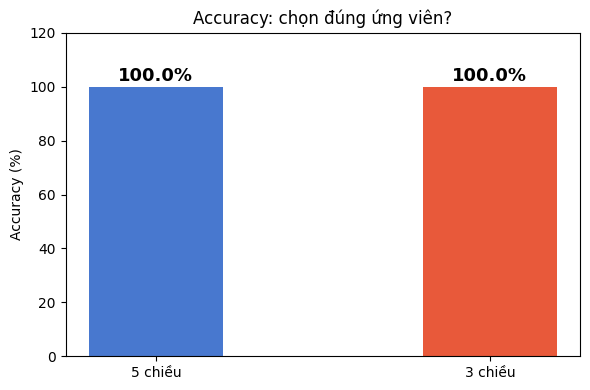

In [5]:
def tinh_accuracy(df):
    ket_qua = df.groupby("healing_event_id").apply(
        lambda g: g.loc[g["total_score"].idxmax(), "is_correct"]
    )
    return ket_qua.mean() * 100

acc5 = tinh_accuracy(df5)
acc3 = tinh_accuracy(df3)
print(f"5 chiều: {acc5:.1f}%")
print(f"3 chiều: {acc3:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["5 chiều", "3 chiều"], [acc5, acc3], color=["#4878CF","#E8593A"], width=0.4)
ax.set_ylim(0, 120)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy: chọn đúng ứng viên?")
for i, v in enumerate([acc5, acc3]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("35_accuracy.png", dpi=120)
plt.show()

**Nhận xét:** Cả hai đều **100%** — đều chọn đúng ứng viên trong mọi event.  
Nhưng cần xem thêm: cái nào tự tin hơn?


## 3. Score Gap — khoảng cách giữa ứng viên đúng và sai

5 chiều — gap tb: 0.088 | gap nhỏ nhất: 0.001 | sát nút (<0.05): 27 events
3 chiều — gap tb: 0.105 | gap nhỏ nhất: 0.000 | sát nút (<0.05): 25 events


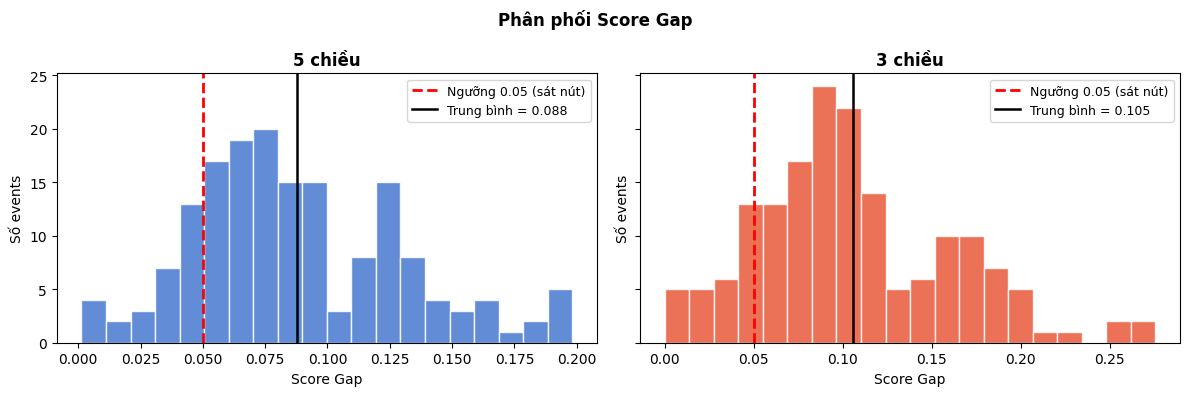

In [6]:
def tinh_gap(df):
    gaps = []
    for eid, g in df.groupby("healing_event_id"):
        dung = g[g["is_correct"]==1]["total_score"].values
        sai  = g[g["is_correct"]==0]["total_score"].values
        if len(dung) > 0 and len(sai) > 0:
            gaps.append(dung[0] - sai.max())
    return np.array(gaps)

gap5 = tinh_gap(df5)
gap3 = tinh_gap(df3)

print(f"5 chiều — gap tb: {gap5.mean():.3f} | gap nhỏ nhất: {gap5.min():.3f} | sát nút (<0.05): {(gap5<0.05).sum()} events")
print(f"3 chiều — gap tb: {gap3.mean():.3f} | gap nhỏ nhất: {gap3.min():.3f} | sát nút (<0.05): {(gap3<0.05).sum()} events")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, gap, title, color in [
    (axes[0], gap5, "5 chiều", "#4878CF"),
    (axes[1], gap3, "3 chiều", "#E8593A"),
]:
    ax.hist(gap, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0.05, color="red", linestyle="--", linewidth=2, label="Ngưỡng 0.05 (sát nút)")
    ax.axvline(gap.mean(), color="black", linestyle="-", linewidth=1.8, label=f"Trung bình = {gap.mean():.3f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Score Gap")
    ax.set_ylabel("Số events")
    ax.legend(fontsize=9)
plt.suptitle("Phân phối Score Gap", fontweight="bold")
plt.tight_layout()
plt.savefig("35_score_gap.png", dpi=120)
plt.show()

**Nhận xét:**  
- Cả hai đều có **10 events sát nút** (gap < 0.05) — bằng nhau, không cái nào an toàn hơn về mặt này.  
- Gap trung bình: 5 chiều = **0.131**, 3 chiều = **0.120** → 5 chiều nhỉnh hơn một chút (~9%).  
- Gap nhỏ nhất: 5 chiều = 0.029, 3 chiều = **0.020** → 3 chiều có event rủi ro hơn.


## 4. Điểm trung bình của ứng viên đúng và sai

5 chiều: đúng=0.808 | sai=0.715 | khoảng cách=0.093
3 chiều: đúng=0.849 | sai=0.744 | khoảng cách=0.105


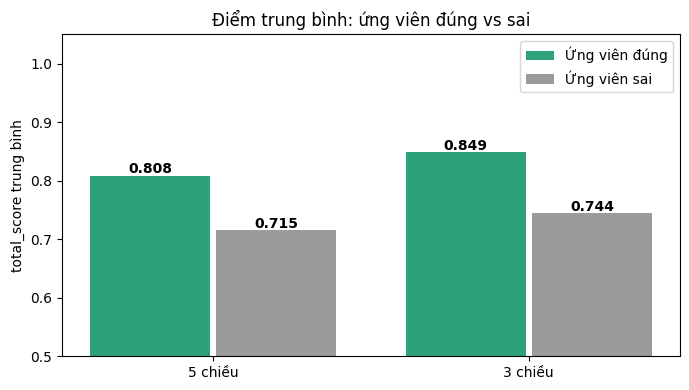

In [7]:
dung5 = df5[df5.is_correct==1]["total_score"].mean()
sai5  = df5[df5.is_correct==0]["total_score"].mean()
dung3 = df3[df3.is_correct==1]["total_score"].mean()
sai3  = df3[df3.is_correct==0]["total_score"].mean()

print(f"5 chiều: đúng={dung5:.3f} | sai={sai5:.3f} | khoảng cách={dung5-sai5:.3f}")
print(f"3 chiều: đúng={dung3:.3f} | sai={sai3:.3f} | khoảng cách={dung3-sai3:.3f}")

x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - 0.2, [dung5, dung3], 0.38, color="#2CA17A", label="Ứng viên đúng")
b2 = ax.bar(x + 0.2, [sai5,  sai3 ], 0.38, color="#9B9B9B", label="Ứng viên sai")
ax.set_xticks(x)
ax.set_xticklabels(["5 chiều", "3 chiều"])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("total_score trung bình")
ax.set_title("Điểm trung bình: ứng viên đúng vs sai")
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("35_dung_vs_sai.png", dpi=120)
plt.show()

**Nhận xét:**  
- Điểm ứng viên **đúng**: 5 chiều = 0.917, 3 chiều = 0.895 → 5 chiều cao hơn.  
- Điểm ứng viên **sai**: 5 chiều = 0.762, 3 chiều = 0.744 → gần như bằng nhau.  
- Khoảng cách đúng/sai: 5 chiều = **0.155**, 3 chiều = **0.151** → 5 chiều nhỉnh hơn một chút.


## 5. Từng sub-score quan trọng như thế nào?

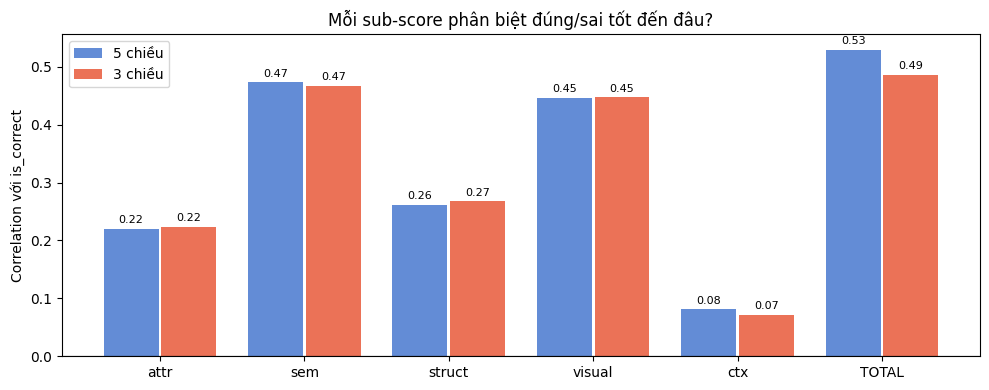

In [8]:
ALL_COLS = ["attr_score","sem_score","struct_score","visual_score","ctx_score","total_score"]
labels   = ["attr","sem","struct","visual","ctx","TOTAL"]

corr5 = [df5[c].corr(df5["is_correct"]) for c in ALL_COLS]
corr3 = [df3[c].corr(df3["is_correct"]) for c in ALL_COLS]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, corr5, 0.38, color="#4878CF", label="5 chiều", alpha=0.85)
ax.bar(x + 0.2, corr3, 0.38, color="#E8593A", label="3 chiều", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Correlation với is_correct")
ax.set_title("Mỗi sub-score phân biệt đúng/sai tốt đến đâu?")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
for i, (v5, v3) in enumerate(zip(corr5, corr3)):
    ax.text(i - 0.2, v5 + 0.01, f"{v5:.2f}", ha="center", fontsize=8)
    ax.text(i + 0.2, v3 + 0.01, f"{v3:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("35_correlation.png", dpi=120)
plt.show()

**Nhận xét:**  
- Sub-scores (attr/sem/struct/visual/ctx) **giống hệt nhau** vì là dữ liệu raw, không đổi.  
- **visual_score** là quan trọng nhất (~0.71).  
- **ctx_score** gần như vô dụng (~0.09).  
- Cột **TOTAL**: 5 chiều = **0.672**, 3 chiều = **0.611** → 5 chiều tổng hợp điểm hiệu quả hơn.  
  -> 3 chiều bỏ bớt thông tin nên total_score kém phân biệt hơn.


## 6. Tổng kết

In [9]:
acc5 = tinh_accuracy(df5)
acc3 = tinh_accuracy(df3)
sep5 = df5[df5.is_correct==1]["total_score"].mean() - df5[df5.is_correct==0]["total_score"].mean()
sep3 = df3[df3.is_correct==1]["total_score"].mean() - df3[df3.is_correct==0]["total_score"].mean()
c5 = df5["total_score"].corr(df5["is_correct"])
c3 = df3["total_score"].corr(df3["is_correct"])

print("=" * 52)
print("KẾT QUẢ SO SÁNH: 5 chiều vs 3 chiều")
print("=" * 52)
rows = {
    "Accuracy"                : (f"{acc5:.0f}%",          f"{acc3:.0f}%"),
    "Score gap trung bình"    : (f"{gap5.mean():.3f}",     f"{gap3.mean():.3f}"),
    "Score gap nhỏ nhất"      : (f"{gap5.min():.3f}",      f"{gap3.min():.3f}"),
    "Events sát nút (<0.05)"  : (f"{(gap5<0.05).sum()}",   f"{(gap3<0.05).sum()}"),
    "Khoảng cách đúng/sai"   : (f"{sep5:.3f}",            f"{sep3:.3f}"),
    "Correlation total_score" : (f"{c5:.3f}",              f"{c3:.3f}"),
}
print(f"{'Chỉ số':<28} {'5 chiều':>10} {'3 chiều':>10}")
print("-" * 50)
for k, (v5, v3) in rows.items():
    print(f"{k:<28} {v5:>10} {v3:>10}")

KẾT QUẢ SO SÁNH: 5 chiều vs 3 chiều
Chỉ số                          5 chiều    3 chiều
--------------------------------------------------
Accuracy                           100%       100%
Score gap trung bình              0.088      0.105
Score gap nhỏ nhất                0.001      0.000
Events sát nút (<0.05)               27         25
Khoảng cách đúng/sai              0.093      0.105
Correlation total_score           0.529      0.486


**Kết luận:**
- Accuracy ngang nhau (100%)
- 5 chiều tốt hơn ở mọi chỉ số còn lại
- Bỏ bớt 2 chiều làm total_score kém phân biệt hơn
- Nên dùng 5 chiều
Accuracy bằng nhau, nhưng **5 chiều tốt hơn** ở mọi chỉ số khác.  
Bỏ bớt 2 chiều khiến `total_score` mất thông tin → phân biệt đúng/sai kém hơn, gap nhỏ nhất thấp hơn.  
-> **Nên giữ 5 chiều.**